In [8]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import sys
initial_path=os.getcwd()
sys.path.append('/Users/valerio/Documents/Borelli/These/Coordinated Motifs')
from data.tools import create_armcoda_signal_from_idxes, dict_to_mask, mask_to_dict
os.chdir(initial_path)
arm_coda_path=initial_path +'/../data/arm-CODA-raw-dataset/dataset/'


In [17]:
import matplotlib.pyplot as plt
import numpy as np


def plot_signal_and_submotifs(
    signal,
    motifs,
    motif_dims,
    plain_figure=False,
    motif_style="rectangle",
    axes=None,
    figsize=None,
    group_names=None,
    colors=None,
    show_frame=True,
    save_path=None,
    hspace=0.05,
    non_motif_color="grey",
    motif_linewidth=2,
    rectangle_alpha=0.3,
    bbox_inches="tight"
):
    """
    Plot a multivariate signal with submotifs highlighted.

    Parameters
    ----------
    signal : ndarray of shape (n_samples, n_dimensions)
        Multivariate time series.

    motifs : ndarray
        Binary motif masks. Expected shape:
        (n_motifs, n_samples).

    motif_dims : list[list[int]]
        Active dimensions associated with each motif.

    plain_figure : bool, default=False
        If True, remove ticks, axis labels, and legend.
        This parameter does not control how motifs are displayed.

    motif_style : {"line", "rectangle"}, default="rectangle"
        Representation of motif occurrences:

        - "line": recolor the signal during motif occurrences.
        - "rectangle": highlight motif occurrences in the background.

    axes : array-like of matplotlib.axes.Axes, optional
        Existing axes on which to draw.

    figsize : tuple, optional
        Figure size. By default: (10, 2 * n_dimensions).

    group_names : list[str], optional
        Vertical labels for pairs of dimensions.

        Example for four dimensions:
        ["Left hand", "Right hand"]

        "Left hand" spans dimensions 0-1 and "Right hand" spans
        dimensions 2-3.

    colors : list or dict, optional
        Motif colors.

        Examples:
        ["red", "blue", "#00ff00"]
        {0: "red", 1: (0.2, 0.8, 0.4)}

        By default, the tab10 palette is used.

    show_frame : bool, default=True
        Whether subplot spines are visible.
        This is independent of plain_figure.

    hspace : float, default=0.05
        Vertical space between subplots.

    non_motif_color : matplotlib color, default="grey"
        Color of the original signal.

    motif_linewidth : float, default=2
        Width of motif segments when motif_style="line".

    rectangle_alpha : float, default=0.3
        Transparency of highlighted regions when
        motif_style="rectangle".
    """
    if motif_style not in {"line", "rectangle"}:
        raise ValueError(
            "`motif_style` must be either 'line' or 'rectangle'."
        )

    signal = np.asarray(signal)
    motifs = np.asarray(motifs).T

    n_samples, n_dimensions = signal.shape
    n_motifs = motifs.shape[1]

    if motifs.shape[0] != n_samples:
        raise ValueError(
            "After transposition, `motifs` must have one row per sample. "
            f"Received {motifs.shape[0]} motif samples for "
            f"{n_samples} signal samples."
        )

    # ── Résolution des couleurs ──────────────────────────────────────────────
    def resolve_colors(input_colors, number_of_motifs):
        if input_colors is None:
            return {
                motif: plt.cm.tab10(motif % 10)
                for motif in range(number_of_motifs)
            }

        if isinstance(input_colors, dict):
            return {
                motif: input_colors.get(
                    motif,
                    plt.cm.tab10(motif % 10),
                )
                for motif in range(number_of_motifs)
            }

        if len(input_colors) == 0:
            raise ValueError("`colors` cannot be an empty sequence.")

        return {
            motif: input_colors[motif % len(input_colors)]
            for motif in range(number_of_motifs)
        }

    motif_colors = resolve_colors(colors, n_motifs)

    # ── Mise en place de la figure ───────────────────────────────────────────
    if figsize is None:
        figsize = (10, 2 * n_dimensions)

    external_axes = axes is not None

    if not external_axes:
        fig, axes = plt.subplots(
            n_dimensions,
            1,
            figsize=figsize,
            sharex=True,
            squeeze=False,
        )
        axes = axes[:, 0]
    else:
        axes = np.atleast_1d(axes)
        fig = axes[0].figure

    if len(axes) != n_dimensions:
        raise ValueError(
            f"Expected {n_dimensions} axes, received {len(axes)}."
        )

    # ── Tracé du signal et des motifs ────────────────────────────────────────
    for dimension in range(n_dimensions):
        ax = axes[dimension]

        ax.plot(
            signal[:, dimension],
            color=non_motif_color,
            linewidth=1,
        )

        # Les limites sont récupérées après le tracé du signal afin que
        # les rectangles couvrent toute la hauteur du subplot.
        y_min, y_max = ax.get_ylim()

        for motif in range(n_motifs):
            if dimension not in motif_dims[motif]:
                continue

            mask = motifs[:, motif] == 1

            if motif_style == "line":
                y_masked = np.full(n_samples, np.nan)
                y_masked[mask] = signal[mask, dimension]

                ax.plot(
                    y_masked,
                    color=motif_colors[motif],
                    linewidth=motif_linewidth,
                )

            else:
                ax.fill_between(
                    np.arange(n_samples),
                    y_min,
                    y_max,
                    where=mask,
                    color=motif_colors[motif],
                    alpha=rectangle_alpha,
                    step="mid",
                )

        if plain_figure:
            ax.set_xticks([])
            ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(show_frame)

    # ── Labels verticaux de groupe ───────────────────────────────────────────
    if group_names is not None:
        # Nécessaire pour obtenir les positions définitives des axes.
        fig.canvas.draw()

        for group_index, name in enumerate(group_names):
            first_dimension = 2 * group_index
            second_dimension = first_dimension + 1

            if second_dimension >= n_dimensions:
                break

            first_position = axes[first_dimension].get_position()
            second_position = axes[second_dimension].get_position()

            y_center = (
                first_position.y1 + second_position.y0
            ) / 2

            fig.text(
                0.03,
                y_center,
                name,
                rotation=90,
                va="center",
                ha="center",
                fontsize=11,
                fontweight="bold",
            )

    # ── Cas d'axes fournis extérieurement ────────────────────────────────────
    if external_axes:
        return

    # ── Légende et labels ────────────────────────────────────────────────────
    if not plain_figure:
        if motif_style == "rectangle":
            handles = [
                plt.Rectangle(
                    (0, 0),
                    1,
                    1,
                    color=motif_colors[motif],
                    alpha=rectangle_alpha,
                )
                for motif in range(n_motifs)
            ]
        else:
            handles = [
                plt.Line2D(
                    [0],
                    [0],
                    color=motif_colors[motif],
                    linewidth=motif_linewidth,
                )
                for motif in range(n_motifs)
            ]

        labels = [
            f"Motif {motif + 1}"
            for motif in range(n_motifs)
        ]

        fig.legend(
            handles,
            labels,
            loc="upper right",
        )

        axes[-1].set_xlabel("Temps")

    plt.tight_layout(rect=(0.03, 0, 1, 1))
    plt.subplots_adjust(hspace=hspace)
    if save_path is not None:
        fig.savefig(
            save_path,
            format="pdf",
            bbox_inches=bbox_inches,
        )
    plt.show()

In [13]:
hand_sensors = [20,29]
dimension_mask = []
right_hand_dims = [20*3+1, 20*3+2]
left_hand_dims = [29*3+1, 29*3+2]

idxes_list=[[5,10,1],[5,13,1],[5,10,2],[5,13,2]]
signal,mask,idxes_list=create_armcoda_signal_from_idxes(idxes_list,save=False,sparsity=0.8, sparsity_fluctuation=0.2, id='mvts_0_7',path=arm_coda_path)

filtered_signal=signal[:,left_hand_dims + right_hand_dims]
dimensions=[]
dimensions.append([0,1,2,3])
dimensions.append([2,3])

dim_names= ["Left hand", "Right hand"]

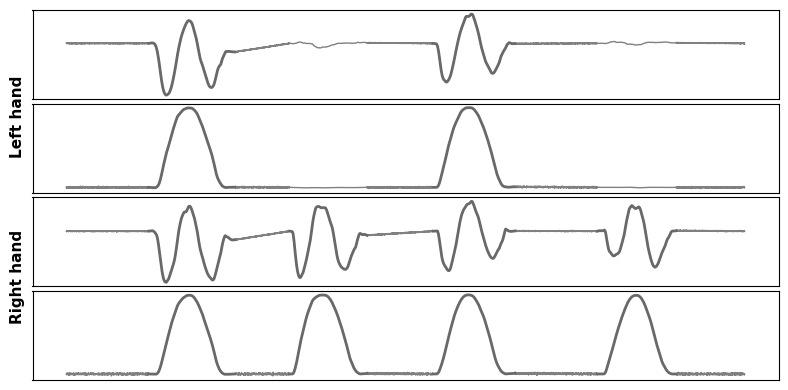

In [14]:
plot_signal_and_submotifs(filtered_signal,mask, motif_dims=dimensions, motif_style='line',plain_figure=True,figsize=(8,4), group_names=dim_names,colors=['dimgray','dimgray'])

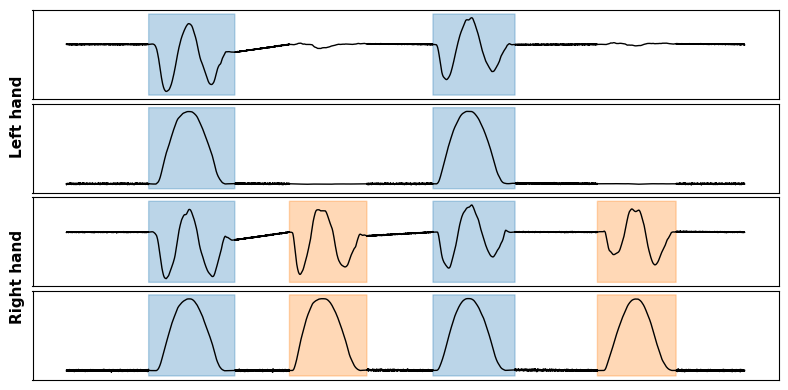

In [22]:
plot_signal_and_submotifs(filtered_signal, mask, motif_dims=dimensions, non_motif_color='black',plain_figure=True,figsize=(8,4), group_names=dim_names, save_path='armcoda_figures/decomposition_1.pdf')

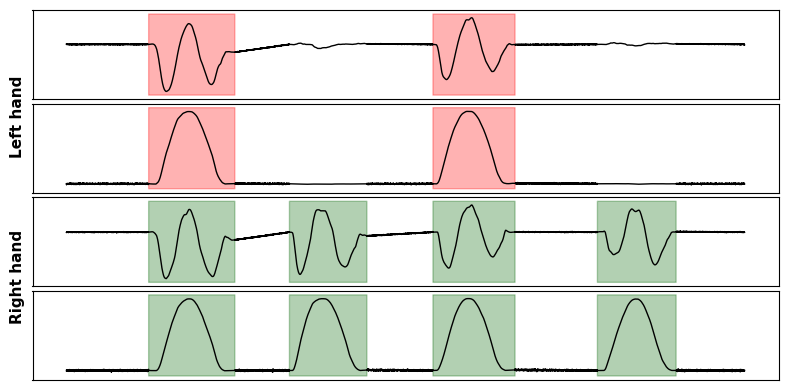

In [23]:
other_mask = np.zeros_like(mask)
other_mask[0]=mask[0]+mask[1]
other_mask[1]= mask[0]
other_dimensions =[[2,3],[0,1]] 
plot_signal_and_submotifs(filtered_signal, other_mask, motif_dims=other_dimensions, non_motif_color='black', plain_figure=True,figsize=(8,4), group_names=dim_names, colors = ['darkgreen', 'red'],save_path='armcoda_figures/decomposition_2.pdf')